# MLP (Multi-Layer-Perceptron) with OHE Features
### ------ NFL TV Ratings (Neural Network)

## Module Imports

This notebook is the first of two portfolio MLP notebooks. The foundational MLP math
(ReLU, weight initialization, forward/backprop, Adam) is derived step by step in the
sections below. These derivations live here so this notebook stands alone as a complete
reference. The implementations are shared across both MLP notebooks (other one is `MLP_embeddings_tv_ratings.ipynb`) via three modules:

- `MLP_core.py`: pure-NumPy MLP primitives: `relu`, `deriv_relu`, `init_params`, `init_adam_state`, `forward_prop`, `back_prop`, `update_params_adam`, `mse_loss`
- `tv_ratings_preprocessing.py`: data preparation utilities: `isdivision`, `encode_categorical`, `build_concurrent_features`
- `MLP_analysis.py`: post-training analysis: `run_permutation_importance`, `plot_actual_vs_predicted`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import r2_score

# custom module imports
from tv_ratings_preprocessing import isdivision, encode_categorical, build_concurrent_features, build_normalized_market_draw
from MLP_core import (relu, deriv_relu, mse_loss, init_params, init_adam_state,
                      update_params_adam, forward_prop, back_prop)
from MLP_analysis import run_permutation_importance, plot_actual_vs_predicted, plot_subset_r2

## 1. Data Loading

In [2]:
# the data in data_path is the result of our SQL project generate_dataset.py
data_path = r'C:/Users/ASR10/PyPr/nfl_python_local/111B/nfl_python/nfl_data_pipeline/NFLTV_ML_11_rebuilt.csv'
df = pd.read_csv(data_path)
df = df[df['Day'] == 'Sun'].copy()                  # This is intended to be a non-prime-time dataset, but some snuck in, we remove them and study them in a separate model
df = df[df['timeofday'] != 'morning'].copy()        # rule out international games (a subset of prime-time games, they take place primarily on sunday morning)
df = df.sort_values('Date').reset_index(drop=True)

predictors_numerical = ['prev_market_at_year_avg',
'prev_market_ht_year_avg',
'prev_year_at_market_trend_todate',
'prev_year_ht_market_trend_todate',
'prev_year_at_market_trend_4',
'prev_year_ht_market_trend_4',
'prev_year_market_tod_avg',
'prev_market_tod_trend_todate',
'prev_market_tod_trend_4',
'ht_market_todate_prediction',
'ht_market_4_prediction',
'at_market_todate_prediction',
'at_market_4_prediction',
'market_tod_todate_prediction',
'market_tod_4_prediction',
'ht_expected_wins',
'at_expected_wins',
'sum_expected_wins',
'sumwins_m_difwins',
'sumwins_m_difwins_d_week',
'ht_playoff_make_prob',
'ht_playoff_miss_prob',
'at_playoff_make_prob',
'at_playoff_miss_prob',
'ht_division_prob',
'at_division_prob',
'ht_conference_prob',
'at_conference_prob',
'ht_superbowl_prob',
'at_superbowl_prob',
'diff_playoff_make_prob',
'diff_playoff_miss_prob',
'diff_wins',
'sumwins2_diffwins2',
'diff_division_prob',
'diff_conference_prob',
'diff_superbowl_prob',
'normalized_ht_market_draw',
'normalized_at_market_draw',
'week']  # numerical features (scaling to take place below)

predictors_bool = ['playoff_rematch', 'brady', 'rodgers', 'mahomes']  # boolean (passthrough features - no preprocessing needed)

predictors_nominal = ['timeofday', 'Affiliation']  # categorical features (preprocessing needed)

columns = df.columns.values.tolist()
idx = columns.index('Albuqu_primary')
predictors_passthrough = df.columns.values.tolist()[idx:]  # the rest of the boolean/passthrough features, obtained through indexing because of length

target_variable = ['AA__000_']  # Household Average Audience x1000 (how many households watched the game)

df.Date = pd.to_datetime(df.Date)
df.shape

C:\Users\ASR10\AppData\Local\Temp\ipykernel_25480\1308549921.py:3: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


(57229, 2001)

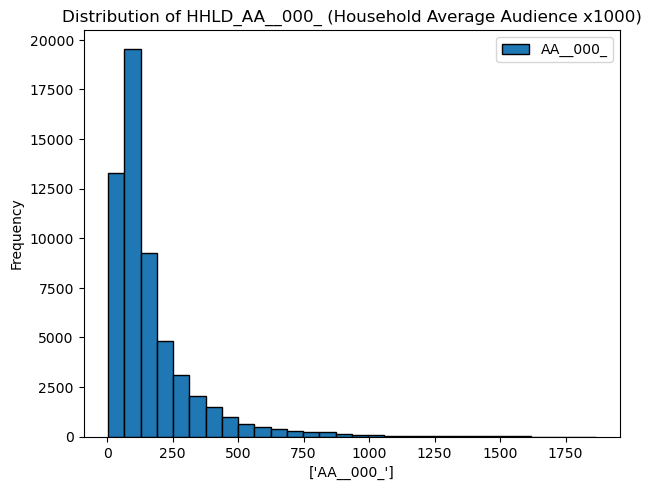

In [3]:
# View Target Distribution variable
df[target_variable].plot(kind='hist', bins=30, edgecolor='black')
plt.xlabel(target_variable)
plt.tight_layout()
plt.title("Distribution of HHLD_AA__000_ (Household Average Audience x1000)")
plt.show()


No log-transforming of the target is necessary in Neural Network modeling

## 2. Feature Engineering

In [4]:
teams = np.unique(df['at'])  # 'at' means 'away_team', and 'ht' means 'home_team'

# integer encode teams
df, at_mapping = encode_categorical(df, 'at')  
df, ht_mapping = encode_categorical(df, 'ht')  # depends on the order teams happen to appear in the db, handled below
df, window_mappinng = encode_categorical(df, 'window')
df, market_mapping = encode_categorical(df, 'Market_abrev')

# Force ht_code to use the same encoding as at_code
at_inv = {team: code for code, team in at_mapping.items()}
df['ht_code'] = df['ht'].map(at_inv)  # overwrite ht_code column by re-encoding every home team using the away teams number scheme


In [5]:
# create matchup strings
# this feature is designed to capture any residual effect two teams have together that is not captured from the sum of their parts. (rivalries)
# note that we only capture this for division opponents - they play twice annually - this ensures there is enough data to potentially capture a signal
# there may be rivalries with non-division opponents but there is likely not enough data to capture a signal. 

matchup_string = []
for i in range(df.shape[0]):
    at = df['at'][i]
    ht = df['ht'][i]
    _, yn, _ = isdivision([at, ht])
    at_idx = teams.tolist().index(at)
    ht_idx = teams.tolist().index(ht)

    # take care to encode div matchups of t1@t2 and t2@t1 the same. 
    if at_idx < ht_idx:
        first_team = at
        second_team = ht
    else:
        first_team = ht
        second_team = at
    if yn == 1:
        matchup_string.append(f"{first_team}_{second_team}")
    else:
        matchup_string.append("Other")

In [6]:
# # Insert the div_matchup column into the dataframe
# insert_pos = df.columns.get_loc('ht') + 1
# df.insert(insert_pos, 'div_matchup', matchup_string)
'''this cell is skipped because our SQL workflow already engineered this feature'''

'this cell is skipped because our SQL workflow already engineered this feature'

In [7]:
# integer encode the division matchups
df, division_mapping = encode_categorical(df, 'div_matchup')

In [8]:
# build_concurrent_features is imported from the shared module, it captures the strength of viewership draw of matchups occuring concurrently.
df = build_concurrent_features(df)

In [9]:
# built_normalized_market_draw is imported from the shared module, captures home/away team's prior-year market avg normalized by that market's average draw
df = build_normalized_market_draw(df, 'AA__000_')

normalized_ht_market_draw:
count    42548.000000
mean         0.992272
std          0.367951
min          0.069906
25%          0.773809
50%          0.961828
75%          1.136732
max          2.833352
Name: normalized_ht_market_draw, dtype: float64
NaN count: 14681 (expected for Season 1 and pre-2014 rows)


In [10]:
## Only use years that have time series data available
df = df[df['Season'] > 2013]
# # df = df[df['timeofday'] != 'evening']
# df

In [11]:
## examine if any rows of the dataframe contain NAN
## evaluate Nans
predictors_target = df.columns.values.tolist() + target_variable
nan_cols = df[predictors_target].isna().any(axis=0).to_list()
np.unique(nan_cols)

array([False,  True])

In [12]:
## examine if any features in the dataset contain NAN ('RTG' is unused)
nan_idx = np.asarray([i for i, x in enumerate(nan_cols) if x])
nan_features = np.array(predictors_target)[nan_idx.astype(int)]
nan_features

array(['RTG'], dtype='<U32')

## 3. Data Assembly

In [13]:
# ------------------ 6. Data Assembly -----------------------------------------
ratings = df['AA__000_'].values.astype(float)  # household average audience x1000

# training data will be games before the start of the 2024 season, validation data will be any games 2024 and after
train_mask_nn = (df['Date'] < '08-01-2024')
tr = np.where( train_mask_nn.values)[0]
va = np.where(~train_mask_nn.values)[0]

# -------------------- Dense features -------------------------------------------------
scaler_num = StandardScaler()
num_raw = df[predictors_numerical].values.astype(float)
scaler_num.fit(num_raw[tr])  # fit scaler on training data only
num_scaled = scaler_num.transform(num_raw)                      # (n, 37)

ohe_tod = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
tod_cols = ohe_tod.fit_transform(df[predictors_nominal])         # (n,  K)

bool_feats = df[predictors_bool].values.astype(float)           # (n,  4)

conc_cont = df[['total_concurrent_popularity',
                'concurrent_count',
                'average_concurrent_popularity']].values.astype(float)
conc_flag = df[['above_19_flag']].values.astype(float)
scaler_conc = StandardScaler()
scaler_conc.fit(conc_cont[tr])
conc_scaled = scaler_conc.transform(conc_cont)                  # (n,  3)

# ----------- Passthrough (binary 0/1, no scaling) --------------------------
passthrough_feats = df[predictors_passthrough].values.astype(float)  # (n, 1904)

# -------------- Window and div_matchup OHE -------------------------------------
ohe_window = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
window_ohe = ohe_window.fit_transform(df[['window_code']])       # (n, N_WINDOWS)

ohe_div = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
div_ohe = ohe_div.fit_transform(df[['div_matchup_code']])        # (n, N_DIV_MATCHUPS)

# ------------------------ Assemble --------------------------------------------------
numericals = np.hstack([
    num_scaled,         # (n, 37)
    tod_cols,           # (n,  K)
    bool_feats,         # (n,  4)
    conc_scaled,        # (n,  3)
    conc_flag,          # (n,  1)
    passthrough_feats,  # (n, 1904)
    window_ohe,         # (n, N_WINDOWS)
    div_ohe,            # (n, N_DIV_MATCHUPS)
]).astype(float)

# --------------------- Column range tracking for permutation importance --------------------------
N_NUMERICAL  = len(predictors_numerical)     # 37
N_TOD        = tod_cols.shape[1]
N_BOOL       = len(predictors_bool)          # 4
N_CONCURRENT = 4                             # 3 scaled + 1 flag
N_DENSE      = N_NUMERICAL + N_TOD + N_BOOL + N_CONCURRENT

N_PASSTHROUGH = len(predictors_passthrough)   # 1904
N_WINDOW_OHE  = window_ohe.shape[1]
N_DIV_OHE     = div_ohe.shape[1]

# Map passthrough column names -> index in numericals
pt_col_to_idx = {col: N_DENSE + i for i, col in enumerate(predictors_passthrough)}

# Classify passthrough columns
team_abbrevs = set(at_mapping.values())
pt_team_mkt = [c for c in predictors_passthrough
                if any(c.endswith(f'_{t}') for t in team_abbrevs)]
pt_slots = [c for c in predictors_passthrough if c not in pt_team_mkt]
pt_primary =   [c for c in pt_slots if 'primary'   in c.lower()]
pt_secondary = [c for c in pt_slots if 'secondary' in c.lower()]

# Group team*market columns by team
team_pt_groups = {}
for team in sorted(team_abbrevs):
    cols = [c for c in pt_team_mkt if c.endswith(f'_{team}')]
    if cols:
        team_pt_groups[team] = cols

# Build perm_groups dict: group_name -> list of column indices in numericals
perm_groups = {}
if pt_primary:
    perm_groups['market_primary']   = [pt_col_to_idx[c] for c in pt_primary]
if pt_secondary:
    perm_groups['market_secondary'] = [pt_col_to_idx[c] for c in pt_secondary]
for team, cols in team_pt_groups.items():
    perm_groups[f'team_{team}'] = [pt_col_to_idx[c] for c in cols]

window_start = N_DENSE + N_PASSTHROUGH
div_start    = window_start + N_WINDOW_OHE
perm_groups['window']      = list(range(window_start, window_start + N_WINDOW_OHE))
perm_groups['div_matchup'] = list(range(div_start,    div_start    + N_DIV_OHE))

print(f'numericals shape : {numericals.shape}')
print(f'  Dense          : {N_DENSE}')
print(f'  Passthrough    : {N_PASSTHROUGH}  '
      f'({len(pt_primary)} primary, {len(pt_secondary)} secondary, '
      f'{len(pt_team_mkt)} team*market)')
print(f'  Window OHE     : {N_WINDOW_OHE}')
print(f'  Div OHE        : {N_DIV_OHE}')
print(f'Train rows : {len(tr)}')
print(f'Val rows   : {len(va)}')
print(f'Permutation groups : {len(perm_groups)}')

numericals shape : (42548, 2016)
  Dense          : 55
  Passthrough    : 1904  (56 primary, 56 secondary, 1792 team*market)
  Window OHE     : 8
  Div OHE        : 49
Train rows : 38443
Val rows   : 4105
Permutation groups : 36


## Architecture

All features are assembled into a single `numericals` matrix of shape `(n, ~2011)`. The MLP takes this directly as input (no embedding lookup, no bilinear interaction like we demonstrate in the embeddings notebook).

```
Input (~2011)
  └─ Dense → 1024 → ReLU
  └─ Dense → 256 → ReLU
  └─ Dense →  64 → ReLU
  └─ Dense →   1 (linear output)
```

The first hidden layer (1024) is intentionally wide relative to the embedding model (245) because the OHE input is high-dimensional and sparse. Each row has exactly 2 of 1792 team×market columns set to 1.

*Implementation in `MLP_core.py`.*

In [14]:
############################################################################################################
         ###################### Architecture Initilization ######################################
############################################################################################################

INPUT_DIM  = numericals.shape[1]
layer_dims = [INPUT_DIM, 1008, 256, 64, 1]
dropout = True             # Dropout Regularization
keep_probs = [.6, .7, .8]  # length should match the number of hidden layers

## Activation Function

**ReLU** (Rectified Linear Unit) is a piecewise linear function:

$$\text{ReLU}(x) = \max(0,\, x) = \begin{cases} x & x > 0 \\ 0 & x \leq 0 \end{cases}$$

Its derivative is also piecewise:

$$\text{ReLU}'(x) = \begin{cases} 1 & x > 0 \\ 0 & x < 0 \end{cases}$$

(undefined at $x = 0$; conventionally set to 0 in practice)

*Implementation in `MLP_core.py`.*

## Weight Initialization Strategies

All three strategies scale weights by $n_{\text{in}}$ (the demensionality of the input to each layer) so that the variance of pre-activations stays approximately constant across layers regardless of depth. Biases are always initialized to zero.

| Strategy | Distribution | Scale factor | Designed for |
|----------|-------------|--------------|--------------|
| **He** (Kaiming, 2015) | $\mathcal{N}(0,\ \sigma^2)$ | $\sigma = \sqrt{2 / n_{\text{in}}}$ | **ReLU**: the factor of 2 compensates for ReLU zeroing roughly half its inputs, which would otherwise halve the variance each layer |
| **Xavier** (Glorot, 2010) | $\mathcal{N}(0,\ \sigma^2)$ | $\sigma = \sqrt{1 / n_{\text{in}}}$ | **Sigmoid / tanh**:  symmetric activations centred at zero; no factor-of-2 correction needed |
| **Uniform** | $\mathcal{U}(-l,\ l)$ | $l = \sqrt{1 / n_{\text{in}}}$ | General fallback; same variance as Xavier but drawn from a uniform rather than normal distribution |

This notebook uses **He initialization** throughout because every hidden layer uses ReLU.

*Implementation in `MLP_core.py`.*

## Forward Propagation

Two variables carry state through each hidden layer:

| Variable | Meaning | Computed by |
|----------|---------|-------------|
| `Z` | **Pre-activation**: the raw linear output before applying ReLU | $Z = W \cdot A_{\text{prev}} + b$ |
| `A` | **Post-activation**: the result after applying ReLU to Z | $A = \text{ReLU}(Z)$ |

`A` is updated each iteration and passed as the input to the next layer. The linear transformation $Z = W \cdot A + b$ has shapes:

$$(\underbrace{n_{\text{out}} \times n_{\text{in}}}_{W}) \cdot (\underbrace{n_{\text{in}} \times m}_{A}) + (\underbrace{n_{\text{out}} \times 1}_{b}) \;\rightarrow\; \underbrace{n_{\text{out}} \times m}_{Z}$$

The bias broadcasts across all $m$ samples in the batch automatically.

*Implementation in `MLP_core.py`.*

## 8. Dropout (Hidden Layer)

Dropout is a regularization technique applied during training: each neuron in a hidden
layer is independently zeroed out with probability $1 - k_p$ on every forward pass.
Surviving neurons are rescaled by $1/k_p$ (inverted dropout) so the expected activation
magnitude is unchanged between training and inference.

The `keep_probs` list has one entry per hidden layer — `[0.7, 0.7, 0.7]` means 30% of
neurons in each hidden layer are dropped each step. At validation, `training=False`
disables dropout and `keep_probs=None` is passed. Dropout can be more effective at the 
initial hidden layers, therefore each layer's dropout percentage can be individually tuned.

Note: this is hidden-layer dropout, applied to neuron *activations* after each ReLU.
The embedding notebook applies dropout at the input representation level — entire
embedding rows are zeroed — which targets a different source of overfitting.

## Backpropagation: Derivatives and Chain Rule

Let $L = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i - y_i)^2$ be the mean squared error loss over a batch of $m$ samples

Backprop applies the chain rule layer-by-layer to compute $\frac{\partial L}{\partial W_l}$ and $\frac{\partial L}{\partial b_l}$ for every layer. At each step we do three things: compute the weight gradient, compute the bias gradient, and hand off the upstream gradient $\delta_{l-1}$ to the layer below.

---

### 1. Output Layer Delta $\delta_L$

The output layer is **linear** ($A_L = Z_L$, no activation), so the chain rule collapses to a direct derivative of MSE with respect to the pre-activation:

$$\frac{\partial L}{\partial Z_L} = \frac{\partial}{\partial Z_L}\left[\frac{1}{m}\sum_{i=1}^{m}(Z_{L,i} - y_i)^2\right] = \frac{2}{m}(Z_L - y)$$

This is `dZ` entering the loop. The $\frac{2}{m}$ factor propagates through and scales every gradient that follows.

---

### 2. Weight Gradient

For any layer $l$, the pre-activation is $Z_l = W_l A_{l-1} + b_l$. Applying the chain rule:

$$\frac{\partial L}{\partial W_l} = \underbrace{\frac{\partial L}{\partial Z_l}}_{\delta_l} \cdot \underbrace{\frac{\partial Z_l}{\partial W_l}}_{A_{l-1}^T}$$

Averaged over the batch:

$$\boxed{\frac{\partial L}{\partial W_l} = \frac{1}{m}\,\delta_l \cdot A_{l-1}^T}$$

The transpose $A_{l-1}^T$ appears because $\delta_l$ has shape $(n_{\text{out}} \times m)$ and $A_{l-1}$ has shape $(n_{\text{in}} \times m)$, so the product $\delta_l \cdot A_{l-1}^T$ produces shape $(n_{\text{out}} \times n_{\text{in}})$, matching $W_l$.

---

### 3. Bias Gradient

Since $\frac{\partial Z_l}{\partial b_l} = 1$ for every sample, the local Jacobian is trivially 1 and the chain rule gives:

$$\boxed{\frac{\partial L}{\partial b_l} = \frac{1}{m}\sum_{i=1}^{m} \delta_{l,i}}$$

Summing (with `keepdims=True`) collapses the $(n_{\text{out}} \times m)$ upstream gradient $\delta_l$ to $(n_{\text{out}} \times 1)$, matching the bias shape.

---

### 4. Propagating $\delta$ Backwards

To compute gradients for layer $l-1$, we need $\delta_{l-1} = \frac{\partial L}{\partial Z_{l-1}}$. The chain rule threads through the ReLU activation sitting between $Z_{l-1}$ and $Z_l$:

$$\frac{\partial L}{\partial Z_{l-1}} = \underbrace{\frac{\partial L}{\partial Z_l}}_{\delta_l} \cdot \underbrace{\frac{\partial Z_l}{\partial A_{l-1}}}_{W_l^T} \cdot \underbrace{\frac{\partial A_{l-1}}{\partial Z_{l-1}}}_{\text{ReLU}'(Z_{l-1})}$$

$$\boxed{\delta_{l-1} = \left(W_l^T \cdot \delta_l\right) \;\odot\; \text{ReLU}'(Z_{l-1})}$$

- $W_l^T \cdot \delta_l$:  routes the upstream error back through the weight matrix; transposed to reverse the forward-pass direction, producing shape $(n_{\text{in}} \times m)$
- $\odot\;\text{ReLU}'(Z_{l-1})$: element-wise mask: any neuron that was inactive ($Z_{l-1} \leq 0$) during the forward pass receives **zero** gradient (dead neuron masking), which is why `deriv_relu` returns a boolean array

*Implementation in `MLP_core.py`.*

## Adam Optimizer

Adam (Adaptive Moment Estimation, Kingma & Ba 2014) combines two prior optimizers (Momentum and RMSProp) and adds bias correction on top.

**Momentum**: steps in the direction of a running exponential average of past gradients rather than the raw current gradient. This results in smoothing noise and helping the optimizer coast through flat regions. Adam inherits this as the **first moment** (`m`).

**RMSProp**: maintains a separate running average of *squared* gradients per parameter, using it to scale down weights with historically large gradients and scale up weights with historically small ones. Adam inherits this as the **second moment** (`v`).

### Why $\beta_1 = 0.9$ and $\beta_2 = 0.999$

Each $\beta$ controls an effective memory window of $\approx 1/(1-\beta)$ gradient steps.

| Moment | $\beta$ | Window | Rationale |
|--------|---------|--------|-----------|
| First (direction) | 0.9 | ~10 steps | Responsive enough to track real shifts in gradient direction; stable enough to filter single-batch noise |
| Second (scale) | 0.999 | ~1,000 steps | Long memory so per-parameter scale estimates don't swing on one unlucky batch |

The second moment window is deliberately much longer than the first: gradient *direction* should be responsive, but gradient *scale*, which governs how much you trust that direction, should be stable. These defaults were established empirically by Kingma & Ba and are rarely changed in practice.

### The Step-Size Insight

The effective learning rate per parameter is approximately $\alpha\,/\,\sqrt{\hat{v}}$. Dense numerical features that fire on every batch accumulate high $\hat{v}$ --> step is damped. Sparse OHE weights that are non-zero in only a handful of rows per batch accumulate low $\hat{v}$ --> step is amplified. Adam automatically re-balances update magnitudes across a heterogeneous feature space.

*Implementation in `MLP_core.py`.*

## 7. Training Loop - Pass 1

Mini-batch Adam over the full `numericals` matrix. Input assembly is a single transpose: `X_b = numericals[batch].T`. No embedding or bilinear machinery.

| Parameter | Value |
|-----------|-------|
| Architecture | [INPUT, 512, 256, 64, 1] |
| Init | He |
| α | 0.0005 |
| β₁ | 0.9 |
| β₂ | 0.999 |
| Batch size | 512 |
| Max epochs | 1000 |
| Patience | 40 |

Input dim  : 2016
MLP params : 2,307,953
Epoch    0 | train R2: 0.0112 | val R2: 0.7494
Epoch   10 | train R2: 0.9067 | val R2: 0.8847
Epoch   20 | train R2: 0.9043 | val R2: 0.8948
Epoch   30 | train R2: 0.9252 | val R2: 0.8884
Epoch   40 | train R2: 0.9313 | val R2: 0.9000
Epoch   50 | train R2: 0.9301 | val R2: 0.8965
Epoch   60 | train R2: 0.9343 | val R2: 0.8901
Epoch   70 | train R2: 0.9392 | val R2: 0.9022

Early stopping at epoch 72. Best val R2: 0.9056


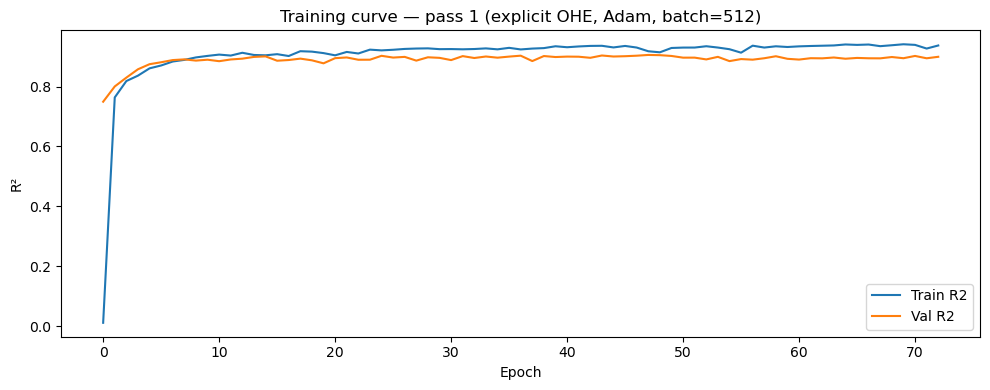

In [15]:
# ------------------------- network config -----------------------------------

# Adam optimizer config
alpha      = 0.0005
beta1      = 0.9
beta2      = 0.999
eps_adam   = 1e-8
n_epochs   = 1000
batch_size = 512
patience   = 25  # early stopping rounds

np.random.seed(42)
params     = init_params(layer_dims, strategy='he')
adam_state = init_adam_state(params)

var_tr = float(np.var(ratings[tr]))
var_va = float(np.var(ratings[va]))

print(f'Input dim  : {INPUT_DIM}')
print(f'MLP params : {sum(v.size for v in params.values()):,}')

# ------------------- training loop -----------------------------------------
tr_losses, va_losses = [], []
tr_r2s,    va_r2s   = [], []
best_val, best_params = np.inf, None
no_improve = 0
t = 0

for epoch in range(n_epochs):  # for each epoch
    perm = np.random.permutation(tr)
    batch_losses = []

    for start in range(0, len(perm), batch_size):  # mini-batch training until full dataset is consumed
        batch = perm[start : start + batch_size] 
        t += 1

        X_b = numericals[batch].T                           # (INPUT_DIM, m)
        if dropout:  # forward prop with dropout
            AL, caches = forward_prop(X_b, params, keep_probs=keep_probs, training=True)
        else:
            AL, caches = forward_prop(X_b, params)

        batch_losses.append(mse_loss(AL, ratings[batch]))  # store losses

        grads, _ = back_prop(AL, ratings[batch], caches, params)  # back propagation
        params, adam_state = update_params_adam(                  # parameter updates
            params, grads, adam_state, alpha, t, beta1, beta2, eps_adam
        )

    # -------------- end-of-epoch validation ---------------------------------
    loss_tr = float(np.mean(batch_losses))
    X_va = numericals[va].T

    if dropout:  # perform forward prop on the validation set only to recieve out-of-sample model estimates
        AL_va, _ = forward_prop(X_va, params, keep_probs=None, training=False)
    else:
        AL_va, _ = forward_prop(X_va, params)

    loss_va = mse_loss(AL_va, ratings[va])

    # R squared calculation on validation set
    r2_tr = 1 - loss_tr / var_tr
    r2_va = 1 - loss_va / var_va
    tr_losses.append(loss_tr);  va_losses.append(loss_va)
    tr_r2s.append(r2_tr);       va_r2s.append(r2_va)

    if epoch % 10 == 0:
        print(f'Epoch {epoch:4d} | train R2: {r2_tr:.4f} | val R2: {r2_va:.4f}')

    if loss_va < best_val:
        best_val    = loss_va
        best_params = {k: v.copy() for k, v in params.items()}
        no_improve  = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'\nEarly stopping at epoch {epoch}. Best val R2: {1 - best_val / var_va:.4f}')
            break

params = best_params

plt.figure(figsize=(10, 4))
plt.plot(tr_r2s, label='Train R2')
plt.plot(va_r2s, label='Val R2')
plt.xlabel('Epoch'); plt.ylabel('R²')
plt.title('Training curve — pass 1 (explicit OHE, Adam, batch=512)')
plt.legend(); plt.tight_layout(); plt.show()

## 9. Permutation Importance (Feature Selection/Pruning)

**Goal:** identify which features the trained model uses, so uninformative ones can be dropped before the final training run.

### Algorithm

1. Compute baseline val MSE: $L_{\text{base}}$
2. For each feature $j$: shuffle column $j$, recompute loss $L_j$, record $\Delta_j = L_j - L_{\text{base}}$
3. Average over $R=5$ independent shuffles to reduce variance by $1/\sqrt{R}$

### Two-tier structure

| Tier | Features | Method |
|------|----------|--------|
| Dense | ~48 numerical/OHE/bool/concurrent columns | Individual column permutation |
| Groups | market slots, per-team interactions, window, div | Group permutation |

**Why groups for passthrough?** Each team×market column has exactly 2 rows set to 1 (home and away team for that market). Permuting a single column gives near-zero delta even for important teams. Grouping all 56 market columns per team into one group yields 32 interpretable importance scores — one per NFL franchise.

**Group permutation:** all columns in the group are shuffled with the *same* row permutation, preserving internal consistency within the group while breaking its relationship with the target.

*Algorithm in `MLP_analysis.py`.*

Baseline val MSE : 1546.1464  |  val R2: 0.9056
Dense permutation complete.
Group permutation complete.


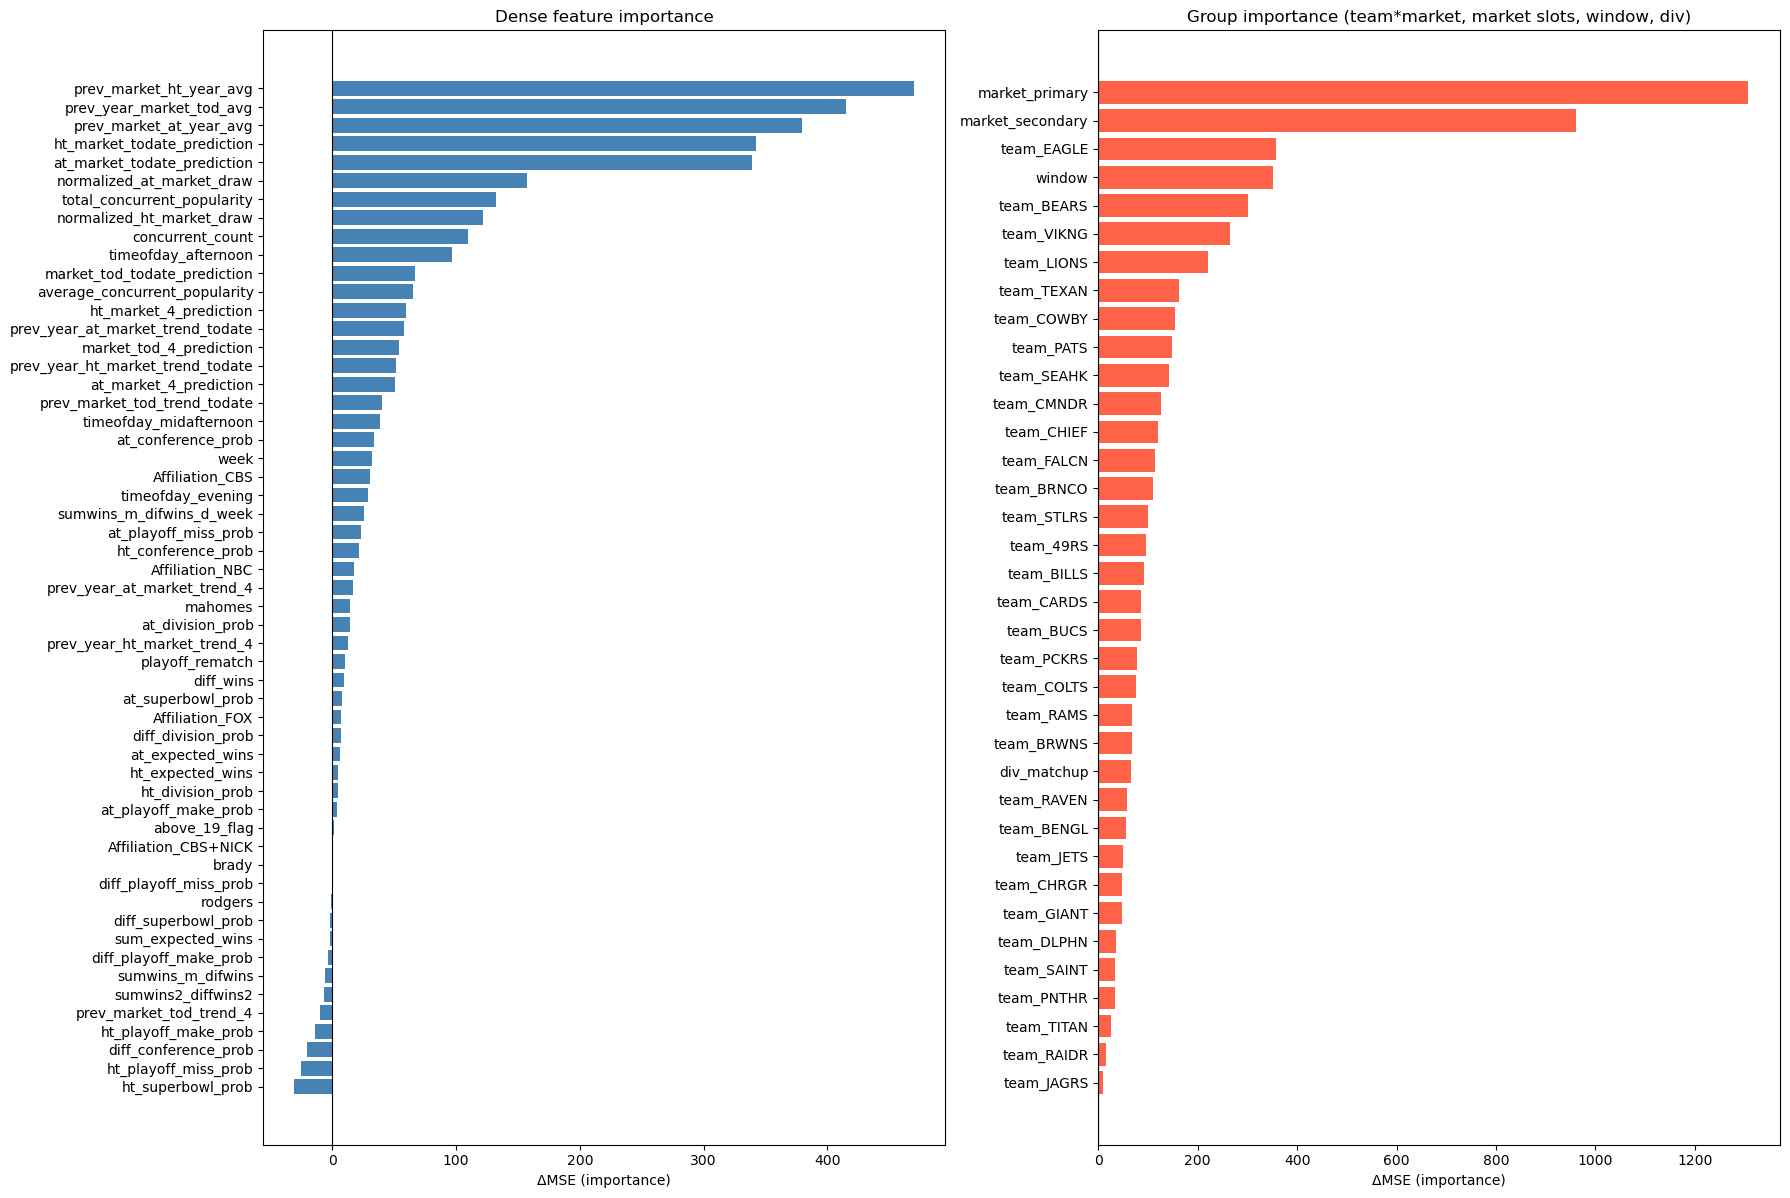


── Dense feature importances (ranked) ──
  prev_market_ht_year_avg                        469.95054
  prev_year_market_tod_avg                       414.74951
  prev_market_at_year_avg                        379.33241
  ht_market_todate_prediction                    341.99554
  at_market_todate_prediction                    339.09729
  normalized_at_market_draw                      157.55744
  total_concurrent_popularity                    132.32643
  normalized_ht_market_draw                      122.06274
  concurrent_count                               109.89417
  timeofday_afternoon                            96.42930
  market_tod_todate_prediction                   67.19769
  average_concurrent_popularity                  64.95170
  ht_market_4_prediction                         59.38807
  prev_year_at_market_trend_todate               58.00854
  market_tod_4_prediction                        53.86026
  prev_year_ht_market_trend_todate               51.25945
  at_market_4_predict

In [16]:
# ------------------- 12. Permutation Importance -------------------------------
num_va_full = numericals[va].copy()

# wrap forward_prop for run_permutation_importance: expects X (m, features) -> (1, m)
predict_fn = lambda X: forward_prop(X.T, params)[0]

# --------------- Dense feature permutation (individual columns 0..N_DENSE-1) ----------------
tod_feat_names = ohe_tod.get_feature_names_out(predictors_nominal).tolist()
dense_names = (predictors_numerical
             + tod_feat_names
             + predictors_bool
             + ['total_concurrent_popularity', 'concurrent_count',
                'average_concurrent_popularity', 'above_19_flag'])
assert len(dense_names) == N_DENSE, f'Name/col mismatch: {len(dense_names)} vs {N_DENSE}'

dense_groups = {dense_names[j]: [j] for j in range(N_DENSE)}
dense_deltas_dict, L_base = run_permutation_importance(predict_fn, num_va_full, ratings[va], dense_groups, n_repeats=5)
deltas_dense = np.array([dense_deltas_dict[n] for n in dense_names])
print(f'Baseline val MSE : {L_base:.4f}  |  val R2: {1 - L_base / var_va:.4f}')
print('Dense permutation complete.')

# ------------ Group permutation (passthrough teams, market slots, window, div) ----------
group_deltas, _ = run_permutation_importance(predict_fn, num_va_full, ratings[va], perm_groups, n_repeats=5)
print('Group permutation complete.')

# ----------------- Plot --------------------------------------------
dense_order = np.argsort(deltas_dense)[::-1]
group_names_sorted = sorted(group_deltas, key=group_deltas.get, reverse=True)
group_vals_sorted = [group_deltas[n] for n in group_names_sorted]

fig, axes = plt.subplots(1, 2, figsize=(18, max(8, len(group_names_sorted) * 0.28 + 2)))

ax = axes[0]
ax.barh([dense_names[i] for i in dense_order[::-1]], deltas_dense[dense_order[::-1]],
        color='steelblue')
ax.set_xlabel('\u0394MSE (importance)')
ax.set_title('Dense feature importance')
ax.axvline(0, color='black', linewidth=0.8)

ax = axes[1]
ax.barh(group_names_sorted[::-1], group_vals_sorted[::-1], color='tomato')
ax.set_xlabel('\u0394MSE (importance)')
ax.set_title('Group importance (team*market, market slots, window, div)')
ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

print('\n\u2500\u2500 Dense feature importances (ranked) \u2500\u2500')
for i in dense_order:
    print(f'  {dense_names[i]:45s}  {deltas_dense[i]:.5f}')

print('\n\u2500\u2500 Group importances (ranked) \u2500\u2500')
for name in group_names_sorted:
    print(f'  {name:40s}  {group_deltas[name]:.5f}')

## 10. Final Training: Trimmed Feature Set

Reinitialize and retrain using only features above the importance threshold.

- **Dense features:** drop individual columns where $\Delta < $ threshold
- **Groups:** drop entire group where $\Delta_{\text{group}} < $ group\_threshold
- **Default threshold:** 1% of baseline val MSE (adjust `threshold` as needed)

`numericals_trim` is assembled by concatenating kept dense columns and all column indices belonging to kept groups.

In [ ]:
# ----------- 10. Final Training — trimmed feature set ---------------------
threshold = 0.00005 * L_base  # essentially all positive contributors
group_threshold = 0.00 * L_base       # keep all categorical data

# Dense trimming
keep_dense_mask = deltas_dense >= threshold
keep_dense_cols = list(np.where(keep_dense_mask)[0])

# Override: features with temporal importance (active during training, rare in val window)
# are kept regardless of their permutation importance score on the val set.
# Example: brady was active 2001-2022 — his column has real signal in training data
# but contributes zero to val importance because he retired before the 2024 val season.
ALWAYS_KEEP_DENSE = ['brady', 'rodgers', 'mahomes']  # e.g. ['brady', 'rodgers', 'mahomes']
always_keep_indices = [i for i, n in enumerate(dense_names) if n in ALWAYS_KEEP_DENSE]
keep_dense_cols = sorted(set(keep_dense_cols) | set(always_keep_indices))

# Group trimming
keep_group_col_indices = []
kept_groups, dropped_groups = [], []
for name, delta in group_deltas.items():
    if delta >= group_threshold:
        keep_group_col_indices.extend(perm_groups[name])
        kept_groups.append(name)
    else:
        dropped_groups.append(name)

all_keep = sorted(set(keep_dense_cols + keep_group_col_indices))
numericals_trim = numericals[:, all_keep]
INPUT_DIM_TRIM = numericals_trim.shape[1]
# layer_dims.remove(INPUT_DIM)
# layer_dims_trim = [INPUT_DIM_TRIM] + layer_dims

layer_dims_trim = [INPUT_DIM_TRIM, 1006, 256, 64, 1]

print(f'Dense features kept : {len(keep_dense_cols)} / {N_DENSE}')
print(f'Groups kept         : {len(kept_groups)} / {len(perm_groups)}')
print(f'Total input dim     : {INPUT_DIM_TRIM}')
print(f'\nDropped dense  : {[dense_names[j] for j in np.where(~keep_dense_mask)[0] if dense_names[j] not in ALWAYS_KEEP_DENSE]}')
print(f'Dropped groups : {dropped_groups}')
if ALWAYS_KEEP_DENSE:
    print(f'Force-kept (ALWAYS_KEEP_DENSE override) : {[n for n in ALWAYS_KEEP_DENSE if n in dense_names]}')

Dense features kept : 43 / 55
Groups kept         : 36 / 36
Total input dim     : 2004

Dropped dense  : ['prev_market_tod_trend_4', 'sum_expected_wins', 'sumwins_m_difwins', 'ht_playoff_make_prob', 'ht_playoff_miss_prob', 'ht_superbowl_prob', 'diff_playoff_make_prob', 'diff_playoff_miss_prob', 'sumwins2_diffwins2', 'diff_conference_prob', 'diff_superbowl_prob', 'Affiliation_CBS+NICK']
Dropped groups : []
Force-kept (ALWAYS_KEEP_DENSE override) : ['brady', 'rodgers', 'mahomes']



Input dim  : 2004
MLP params : 2,291,335
Epoch    0 | train R2: -0.0904 | val R2: 0.7605
Epoch    5 | train R2: 0.8741 | val R2: 0.8799
Epoch   10 | train R2: 0.9025 | val R2: 0.9017
Epoch   15 | train R2: 0.9108 | val R2: 0.9045
Epoch   20 | train R2: 0.9209 | val R2: 0.8971
Epoch   25 | train R2: 0.9177 | val R2: 0.9066
Epoch   30 | train R2: 0.9178 | val R2: 0.8997
Epoch   35 | train R2: 0.9224 | val R2: 0.9030
Epoch   40 | train R2: 0.9288 | val R2: 0.9116
Epoch   45 | train R2: 0.9276 | val R2: 0.9099
Epoch   50 | train R2: 0.9290 | val R2: 0.9122
Epoch   55 | train R2: 0.9277 | val R2: 0.9051
Epoch   60 | train R2: 0.9306 | val R2: 0.9079
Epoch   65 | train R2: 0.9351 | val R2: 0.9043
Epoch   70 | train R2: 0.9401 | val R2: 0.9052
Epoch   75 | train R2: 0.9409 | val R2: 0.8939

Early stopping at epoch 75. Best val R2: 0.9122


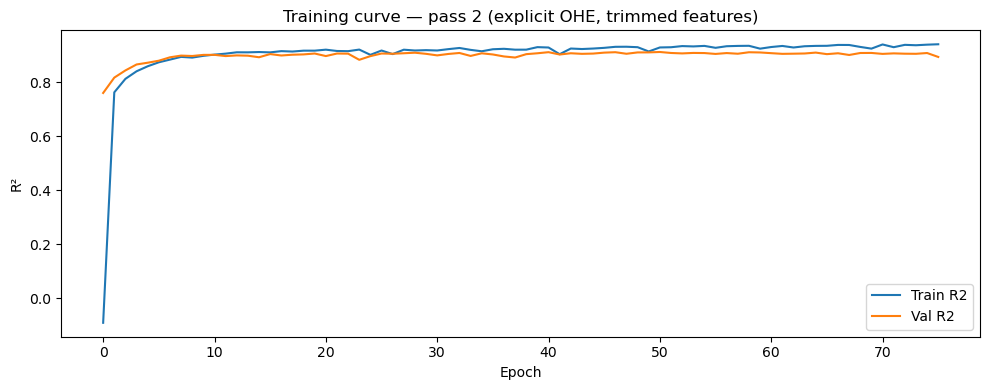

In [19]:

# ------------------------reinitialize ----------------------------------------
np.random.seed(42)
params2 = init_params(layer_dims_trim, strategy='he')
adam_state2 = init_adam_state(params2)

var_tr = float(np.var(ratings[tr]))
var_va = float(np.var(ratings[va]))

print(f'\nInput dim  : {INPUT_DIM_TRIM}')
print(f'MLP params : {sum(v.size for v in params2.values()):,}')

# ------------------------training loop ---------------------------------------------
tr_losses2, va_losses2 = [], []
tr_r2s2,    va_r2s2   = [], []
best_val2, best_params2 = np.inf, None
no_improve2 = 0
t2 = 0

for epoch in range(n_epochs):
    perm = np.random.permutation(tr)
    batch_losses = []

    for start in range(0, len(perm), batch_size):
        batch = perm[start : start + batch_size]
        t2 += 1

        X_b = numericals_trim[batch].T

        if dropout:
            AL, caches = forward_prop(X_b, params2, keep_probs=keep_probs, training=True)
        else:
            AL, caches = forward_prop(X_b, params2)
        
        batch_losses.append(mse_loss(AL, ratings[batch]))

        grads, _ = back_prop(AL, ratings[batch], caches, params2)
        params2, adam_state2 = update_params_adam(
            params2, grads, adam_state2, alpha, t2, beta1, beta2, eps_adam
        )

    loss_tr = float(np.mean(batch_losses))
    X_va = numericals_trim[va].T
    
    if dropout:
        AL_va, _ = forward_prop(X_va, params2, keep_probs=None, training=False)
    else:
        AL_va, _ = forward_prop(X_va, params2)

    loss_va = mse_loss(AL_va, ratings[va])

    r2_tr = 1 - loss_tr / var_tr
    r2_va = 1 - loss_va / var_va
    tr_losses2.append(loss_tr);  va_losses2.append(loss_va)
    tr_r2s2.append(r2_tr);       va_r2s2.append(r2_va)

    if epoch % 5 == 0:
        print(f'Epoch {epoch:4d} | train R2: {r2_tr:.4f} | val R2: {r2_va:.4f}')

    if loss_va < best_val2:
        best_val2 = loss_va
        best_params2 = {k: v.copy() for k, v in params2.items()}
        no_improve2 = 0
    else:
        no_improve2 += 1
        if no_improve2 >= patience:
            print(f'\nEarly stopping at epoch {epoch}. Best val R2: {1 - best_val2 / var_va:.4f}')
            break

params2 = best_params2

plt.figure(figsize=(10, 4))
plt.plot(tr_r2s2, label='Train R2')
plt.plot(va_r2s2, label='Val R2')
plt.xlabel('Epoch'); plt.ylabel('R²')
plt.title('Training curve — pass 2 (explicit OHE, trimmed features)')
plt.legend(); plt.tight_layout(); plt.show()

## 14. Analysis

We evaluate the final trained model on the held-out validation set.

  Val R²        : 0.9122  (raw scale)
  Val R² (log)  : 0.8488  (log1p scale)
  Val RMSE      : 37.91


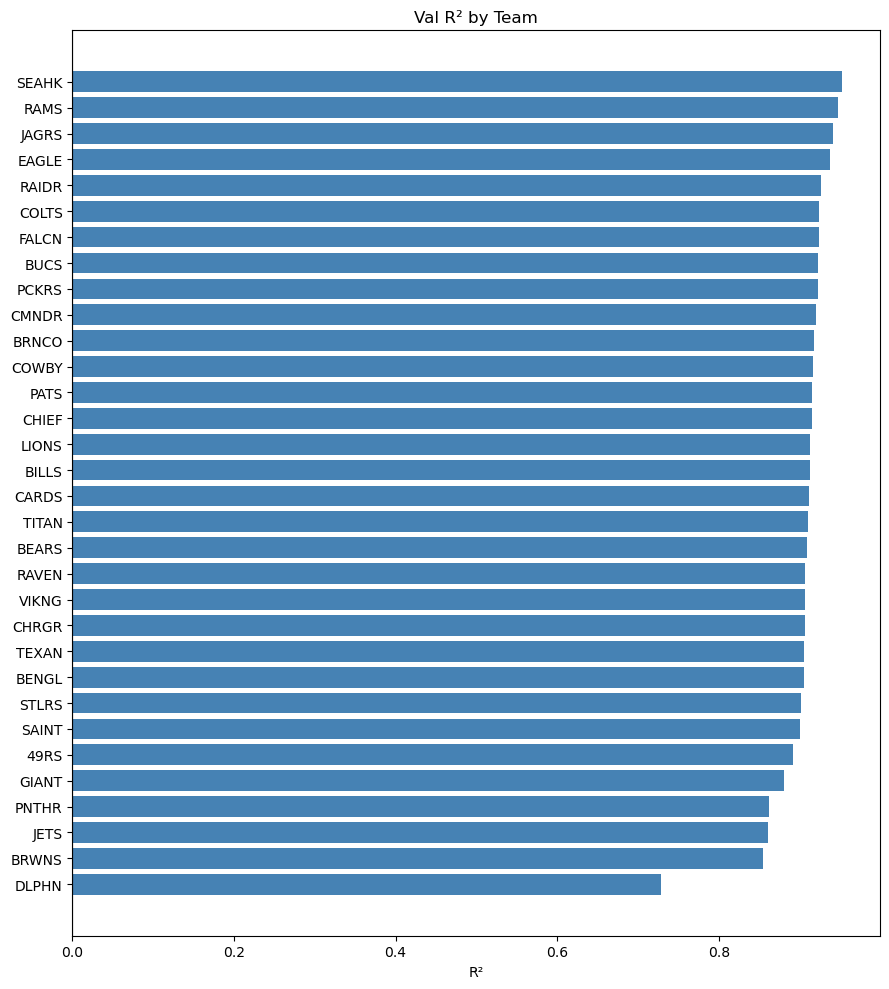

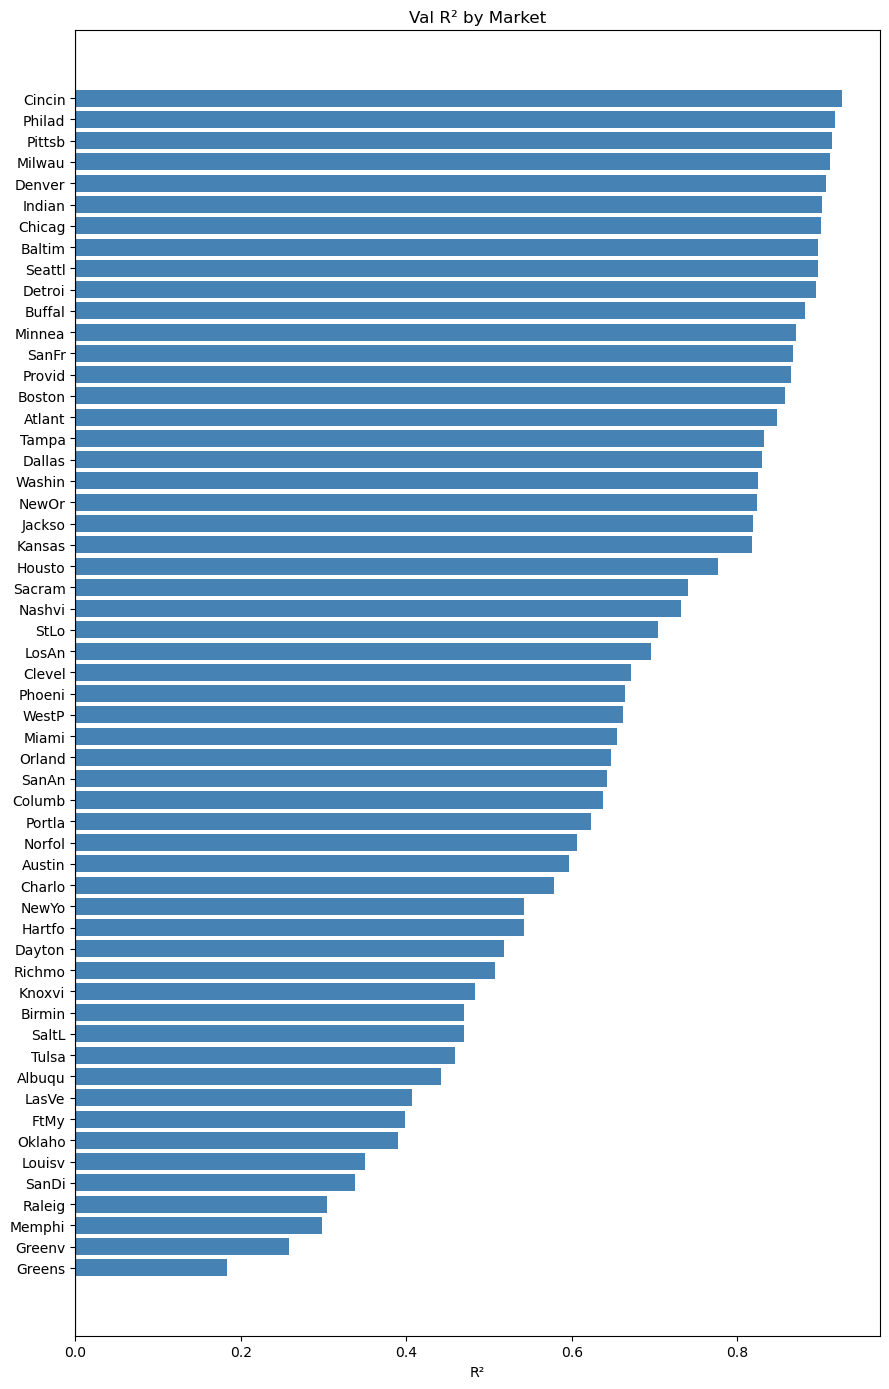

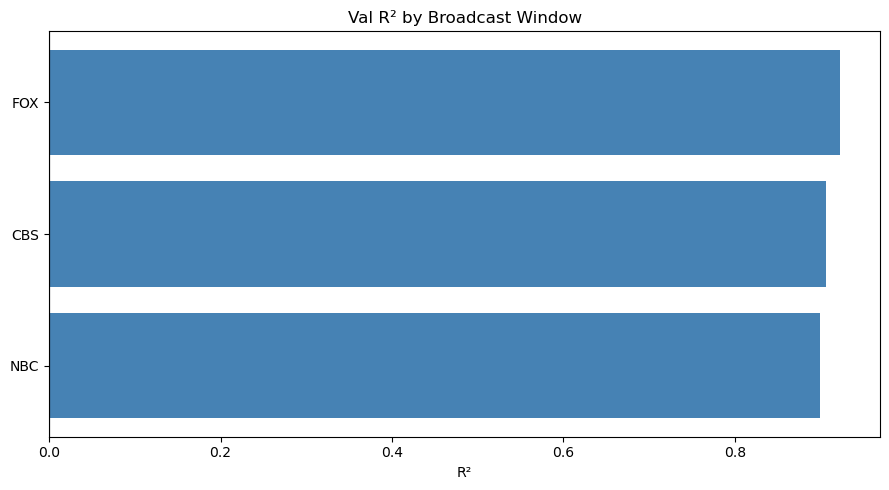


Rating tier accuracy (threshold = 150):
Tier                    n  mean_true  mean_pred     RMSE      MAE
--------------------------------------------------------------
< 150  (low)         2879       79.9       82.0    23.32    17.31
>= 150  (high)       1226      294.0      285.2    59.45    43.65


In [ ]:
# --- 14. Analysis: Actual vs Predicted (Validation Set) ---------------------
X_va = numericals_trim[va].T
AL_va, _ = forward_prop(X_va, params2)
y_pred_va = AL_va.flatten()
y_true_va = ratings[va]

# --- Subset R² breakdowns ----------------------------------------------------
val_df = df.iloc[va].reset_index(drop=True)  # validation set reporting only
home_rows = val_df[['ht', 'Market_abrev']].assign(y_true=y_true_va, y_pred=y_pred_va).rename(columns={'ht': 'team'})
away_rows = val_df[['at', 'Market_abrev']].assign(y_true=y_true_va, y_pred=y_pred_va).rename(columns={'at': 'team'})
val_team  = pd.concat([home_rows, away_rows]).reset_index(drop=True)

# Team-specific reporting
plot_subset_r2(val_team['y_true'].values, val_team['y_pred'].values, val_team['team'].values,
               title='Val R² by Team', figsize=(9, 10))
# Market-specific reporting
plot_subset_r2(y_true_va, y_pred_va, val_df['Market_abrev'].values,
               title='Val R² by Market', figsize=(9, 14))
# Network-specific reporting
plot_subset_r2(y_true_va, y_pred_va, val_df['Affiliation'].values,
               title='Val R² by Broadcast Window', figsize=(9, 5))

# --- Rating tier accuracy (< 150 vs >= 150) ----------------------------- (see if the model is biased toward lower or higher rated games)
print('\nRating tier accuracy (threshold = 150):')
print(f'{"Tier":<18} {"n":>6} {"mean_true":>10} {"mean_pred":>10} {"RMSE":>8} {"MAE":>8}')
print('-' * 62)
for label, mask in [('< 150  (low)', y_true_va < 150), ('>= 150  (high)', y_true_va >= 150)]:
    yt = y_true_va[mask]
    yp = y_pred_va[mask]
    rmse = np.sqrt(np.mean((yt - yp) ** 2))
    mae  = np.mean(np.abs(yt - yp))
    print(f'{label:<18} {mask.sum():>6} {yt.mean():>10.1f} {yp.mean():>10.1f} {rmse:>8.2f} {mae:>8.2f}')


  Val R²        : 0.9122  (raw scale)
  Val R² (log)  : 0.8488  (log1p scale)
  Val RMSE      : 37.91


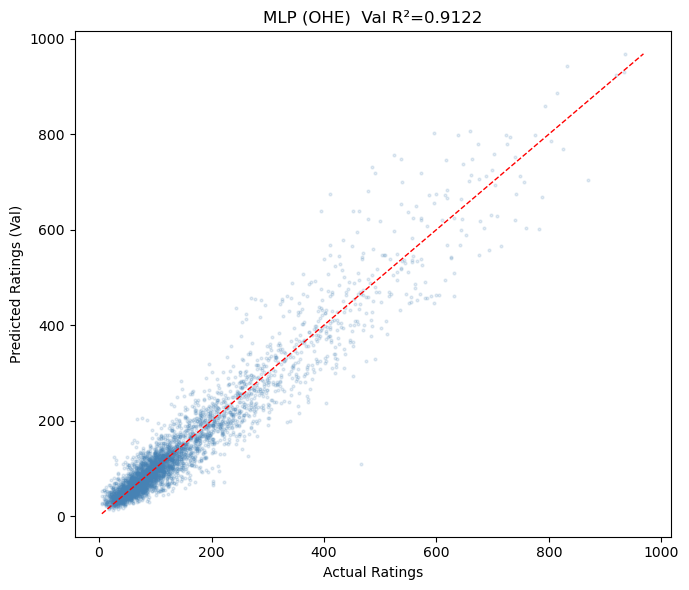

In [23]:
def plot_actual_vs_predicted(y_true, y_pred, title=''):
    # -- Actual vs Predicted (Validation Set) ----------------------------------
    val_r2   = r2_score(y_true, y_pred)
    val_rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

    print('=' * 50)
    print(f'  Val R²        : {val_r2:.4f}  (raw scale)')
    if np.all(y_pred > -1):
        val_r2_log = r2_score(np.log1p(y_true), np.log1p(y_pred))
        print(f'  Val R² (log)  : {val_r2_log:.4f}  (log1p scale)')
    else:
        n_neg = int(np.sum(y_pred <= -1))
        print(f'  Val R² (log)  : n/a  ({n_neg} predictions <= -1, log undefined)')
    print(f'  Val RMSE      : {val_rmse:.2f}')


    # -- scatter plot ----------------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(y_true, y_pred, alpha=0.15, s=4, color='steelblue')
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    ax.set_xlabel('Actual Ratings')
    ax.set_ylabel('Predicted Ratings (Val)')
    ax.set_title(f'{title}  Val R²={val_r2:.4f}' if title else f'Actual vs Predicted — Val R²={val_r2:.4f}')
    plt.tight_layout()
    # plt.show()
    plt.close(fig)
    return fig

plot_actual_vs_predicted(y_true_va, y_pred_va, title='MLP (OHE)')

### OHE Weight Heatmap (team × market)

Each cell below shows the aggregate weight magnitude the first hidden layer assigns to
that team appearing in that market. The OHE analogue to the learned bilinear interaction
matrix in the embedding notebook and the 1:1 feature importance matrix of the Linear Model. High values indicate the network learned a strong
team–market draw signal from the passthrough OHE columns.

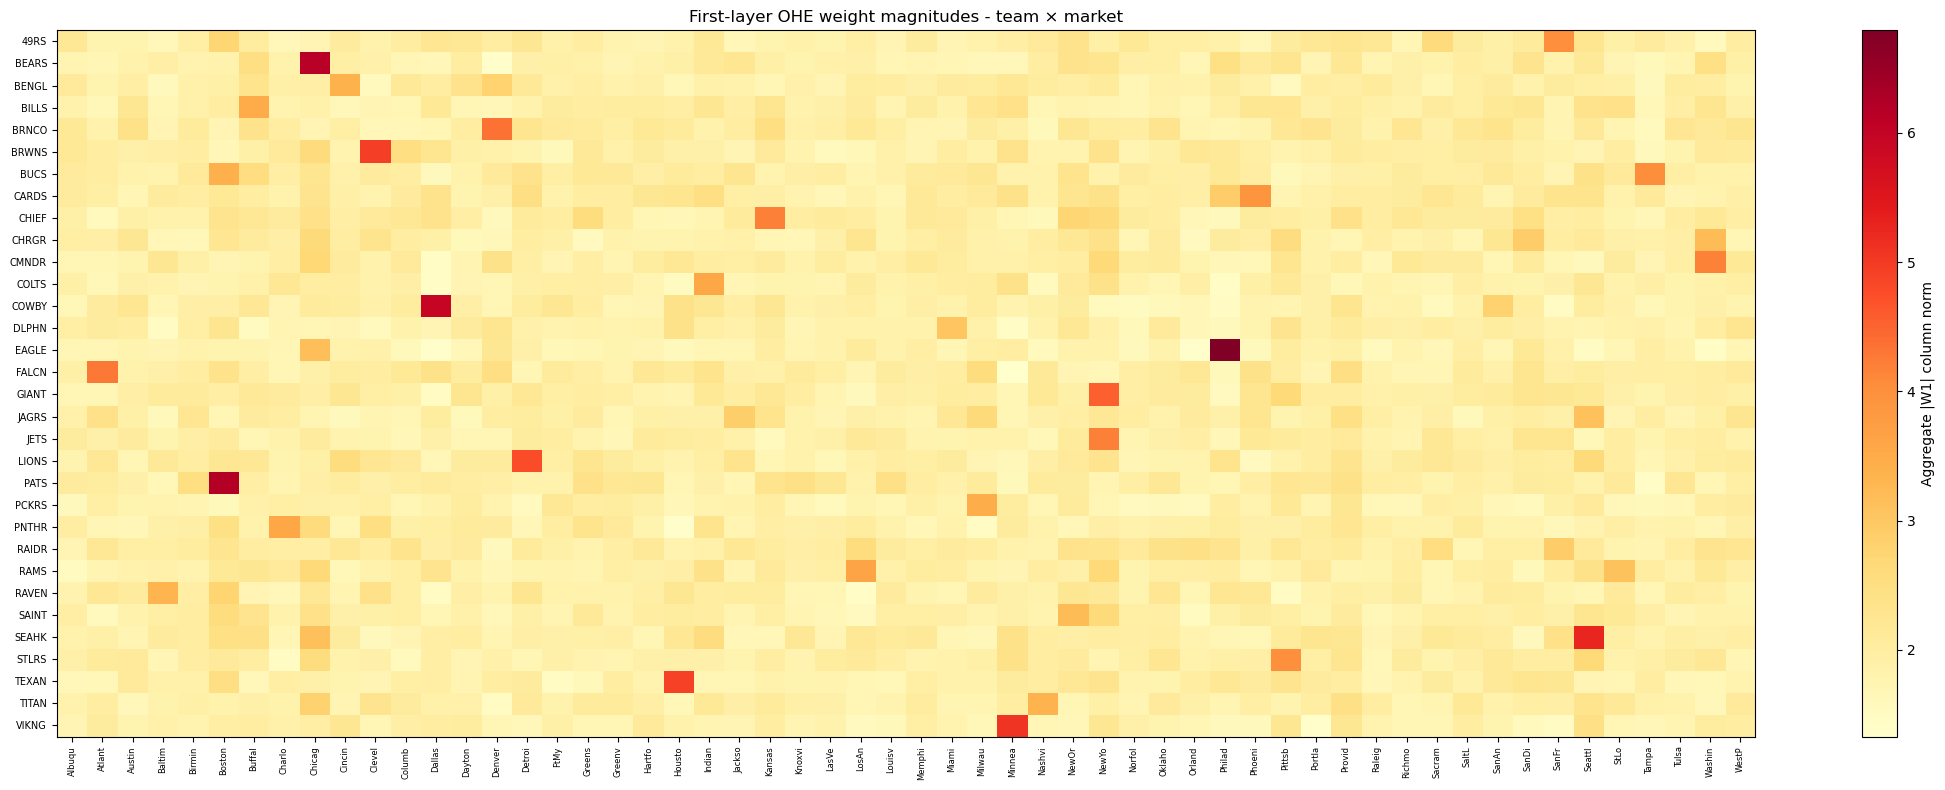

In [22]:
# OHE Weight Heatmap: aggregate first-layer weight magnitude by (team, market)
W1 = params2['W1']                          # shape (n_h1, INPUT_DIM_TRIM)

# Identify where the passthrough team*market OHE block sits in numericals_trim
# all_keep maps trimmed-column positions back to original numericals column indices
pt_start_orig = N_DENSE                     # passthrough block starts here in numericals
pt_end_orig = N_DENSE + N_PASSTHROUGH
pt_cols_in_trim = [i for i, orig in enumerate(all_keep)
                   if pt_start_orig <= orig < pt_end_orig]

if len(pt_cols_in_trim) == 0:
    print('No passthrough OHE columns survived trimming; heatmap not available.')
else:
    # Map each surviving passthrough column back to its (team, market) pair
    pt_orig_indices = [all_keep[i] - N_DENSE for i in pt_cols_in_trim]   # index within predictors_passthrough
    kept_pt_names = [predictors_passthrough[i] for i in pt_orig_indices]

    team_abbrevs_sorted = sorted(at_mapping.values())
    mkt_abbrevs_sorted = sorted(market_mapping.values())

    col_norms = np.linalg.norm(W1[:, pt_cols_in_trim], axis=0)  # (n_kept_pt,)

    heatmap = np.zeros((len(team_abbrevs_sorted), len(mkt_abbrevs_sorted)))
    for col_idx, col_name, norm_val in zip(pt_cols_in_trim, kept_pt_names, col_norms):
        for ti, team in enumerate(team_abbrevs_sorted):
            if col_name.endswith(f'_{team}'):
                for mi, mkt in enumerate(mkt_abbrevs_sorted):
                    if col_name.startswith(mkt) or mkt.lower() in col_name.lower():
                        heatmap[ti, mi] += norm_val
                        break
                break

    fig, ax = plt.subplots(figsize=(22, 8))
    im = ax.imshow(heatmap, aspect='auto', cmap='YlOrRd')
    plt.colorbar(im, ax=ax, label='Aggregate |W1| column norm')
    ax.set_xticks(range(len(mkt_abbrevs_sorted)))
    ax.set_xticklabels(mkt_abbrevs_sorted, rotation=90, fontsize=6)
    ax.set_yticks(range(len(team_abbrevs_sorted)))
    ax.set_yticklabels(team_abbrevs_sorted, fontsize=7)
    ax.set_title('First-layer OHE weight magnitudes - team × market')
    plt.tight_layout()
    plt.show()